In [ ]:
import pandas as pd
from glob import glob
from PIL import Image, ImageDraw
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from ultralytics import YOLO
from tqdm import tqdm
%matplotlib inline

def get_images_labels(path, folder_name):
    """Retrieve sorted lists of label and image file paths for a given folder."""
    labels = glob(f'{path}/train_labels/{folder_name}*')
    labels = sorted(labels)
    imgs = glob(f'{path}/train/{folder_name.split("_")[0]}/{folder_name}*')
    imgs = sorted(imgs)
    return labels, imgs

def generate_random_color():
    """Generate a bright random RGB color."""
    return tuple(random.randint(100, 255) for _ in range(3))

def stack_images_vertically(image_paths):
    """Stack images vertically into a single PIL image, cropping to the minimum width."""
    images = [Image.open(path) for path in image_paths]
    widths, heights = zip(*(i.size for i in images))
    min_width = min(widths)
    total_height = sum(heights)
    stacked_image = Image.new('RGB', (min_width, total_height))
    y_offset = 0
    for im in images:
        if im.width > min_width:
            im = im.crop((0, 0, min_width, im.height))
        stacked_image.paste(im, (0, y_offset))
        y_offset += im.height
    return stacked_image

import os
from PIL import Image

def prepare_stacked_data(image_paths, label_paths):
    """
    Prepare a stacked image and combined mask string from matching image-label pairs.

    Args:
        image_paths (list): List of paths to image files.
        label_paths (list): List of paths to label files.

    Returns:
        tuple: (stacked_image, combined_masks_str)
            - stacked_image: PIL Image object of the stacked images.
            - combined_masks_str: String combining all mask annotations.
    """
    # Create a dictionary mapping label base names to their full paths
    label_map = {os.path.splitext(os.path.basename(lf))[0]: lf for lf in label_paths}
    matching_images = []
    matching_labels = []

    # Match images with corresponding labels
    for image_path in image_paths:
        image_name = os.path.splitext(os.path.basename(image_path))[0]
        if image_name in label_map:
            matching_images.append(image_path)
            matching_labels.append(label_map[image_name])

    # Print feedback for debugging
    # print(f"Found {len(image_paths)} images and {len(label_paths)} labels.")
    # print(f"Matched {len(matching_images)} image-label pairs.")

    # Load and stack the matching images
    images = [Image.open(path) for path in matching_images]
    if len(images) == 0:
        images = [Image.open(path) for path in image_paths]
    widths, heights = zip(*(i.size for i in images))
    min_width = min(widths)
    total_height = sum(heights)

    # Stack images vertically
    stacked_image = Image.new('RGB', (min_width, total_height))
    y_offset = 0
    for im in images:
        im_resized = im.resize((min_width, im.height))
        stacked_image.paste(im_resized, (0, y_offset))
        y_offset += im.height

    # Handle case where no matching pairs are found
    if not matching_images:
        print("No matching image-label pairs found. Just return the image")
        return stacked_image, ""

    # Combine masks with adjusted coordinates
    combined_mask_lines = []
    cumulative_height = 0
    for label_path, im_height, im_width in zip(matching_labels, heights, widths):
        with open(label_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                class_id = parts[0]
                coords = list(map(float, parts[1:]))
                new_coords = []
                for x_norm, y_norm in zip(coords[0::2], coords[1::2]):
                    x_pixel = int(x_norm * im_width)
                    y_pixel = int(y_norm * im_height)
                    x_pixel_cropped = min(x_pixel, min_width - 1)
                    y_pixel_offset = y_pixel + cumulative_height
                    new_x_norm = x_pixel_cropped / min_width
                    new_y_norm = y_pixel_offset / total_height
                    new_coords.extend([new_x_norm, new_y_norm])
                new_line = class_id + " " + " ".join(f"{val:.6f}" for val in new_coords)
                combined_mask_lines.append(new_line)
        cumulative_height += im_height
    combined_masks_str = "\n".join(combined_mask_lines)

    return stacked_image, combined_masks_str

def get_polygons_from_mask_str(mask_str, img_width, img_height):
    polygons = []
    # Split into lines (each line is a polygon)
    lines = mask_str.strip().split('\n') 
    for line in lines:
        # Split line into parts (class ID and coordinates)
        parts = line.strip().split()
        if len(parts) < 3:  # Need at least class ID + one (x, y) pair
            continue
        # Convert coordinates to floats, skipping the class ID
        coords = list(map(float, parts[1:]))
        if len(coords) % 2 != 0:  # Must have even number for (x, y) pairs
            continue
        # Group into (x, y) pairs and convert to pixel coordinates
        points = [(int(x * img_width), int(y * img_height)) 
                  for x, y in zip(coords[0::2], coords[1::2])]
        # Convert to NumPy array and append to list
        polygons.append(np.array(points, dtype=np.int32))
    return polygons
def visualize(stacked_image, polygons):
    # Visualize with polygons
    image = np.array(stacked_image)
    for polygon in polygons:
        if polygon.shape[0]:
            color = generate_random_color()
            cv2.polylines(image, [polygon.astype(int)], isClosed=True, color=color, thickness=1)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [1]:
# Main Execution

# Set paths
PATH = '/raid/ml/root'
train = pd.read_csv(f'{PATH}/Train.csv')
output_dir = f'./seg/images'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(output_dir.replace('images', 'labels'), exist_ok=True)

# 1. Organize Data for Training
for f in tqdm(train.FolderName.unique()):
    for side in ['L', 'R']:
        labels, imgs = get_images_labels(PATH, f'{f}_{side}_')
        if imgs and labels:
            stacked_image, mask_str = prepare_stacked_data(imgs, labels)
            output_path = f'{output_dir}/{f}_{side}.png'
            stacked_image.save(output_path)
            with open(output_path.replace('images', 'labels').replace('.png', '.txt'), 'w') as fx:
                fx.write(mask_str)

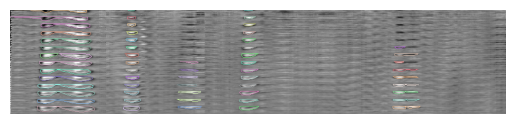

In [2]:
image = Image.open('seg/images/A2miww5mfx_L.png')
w, h = image.size
with open('seg/labels/A2miww5mfx_L.txt') as f:
    mask_str = f.read()
polygons = get_polygons_from_mask_str(mask_str, w, h)
visualize(image, polygons)

In [3]:
# 2. Create YAML Configuration for YOLO
yaml_content = """
path: /raid/ml/root/seg
train: images
val: images
names:
    0: root
"""
with open(f'./seg/config.yaml', 'w') as f:
    f.write(yaml_content.strip())

# 3. Train the Model on Combined Images
model = YOLO("yolo11l-seg.pt")
model.train(data=f"./seg/config.yaml", epochs=100, imgsz=640)

New https://pypi.org/project/ultralytics/8.3.78 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.49 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA RTX A6000, 49140MiB)
engine/trainer: task=segment, mode=train, model=yolo11l-seg.pt, data=./seg/config.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fr

train: Scanning /raid/ml/root/seg/labels.cache... 47 images, 0 backgrounds, 0 corrupt: 100%|██████████| 47/47 [00:00<?, ?it/s]
val: Scanning /raid/ml/root/seg/labels.cache... 47 images, 0 backgrounds, 0 corrupt: 100%|██████████| 47/47 [00:00<?, ?it/s]


Plotting labels to runs/segment/train8/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 176 weight(decay=0.0), 187 weight(decay=0.0005), 186 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/segment/train8
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


       1/10      12.6G      5.074      6.397      4.613      2.229        458        640: 100%|██████████| 3/3 [00:05<00:00,  1.97s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


                   all         47       1964   0.000473    0.00204   0.000238   7.11e-05   0.000827    0.00356   0.000422   0.000212

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         47       1964      0.429      0.352      0.267     0.0827      0.206      0.214      0.112     0.0507



10 epochs completed in 0.010 hours.
Optimizer stripped from runs/segment/train8/weights/last.pt, 55.8MB
Optimizer stripped from runs/segment/train8/weights/best.pt, 55.8MB

Validating runs/segment/train8/weights/best.pt...
Ultralytics 8.3.49 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA RTX A6000, 49140MiB)
YOLO11l-seg summary (fused): 491 layers, 27,585,363 parameters, 0 gradients, 141.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.88it/s]


                   all         47       1964      0.531      0.345      0.321       0.11      0.276      0.202      0.132     0.0589
Speed: 0.1ms preprocess, 4.6ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs/segment/train8


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdb68a1cf10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

No matching image-label pairs found. Just return the image


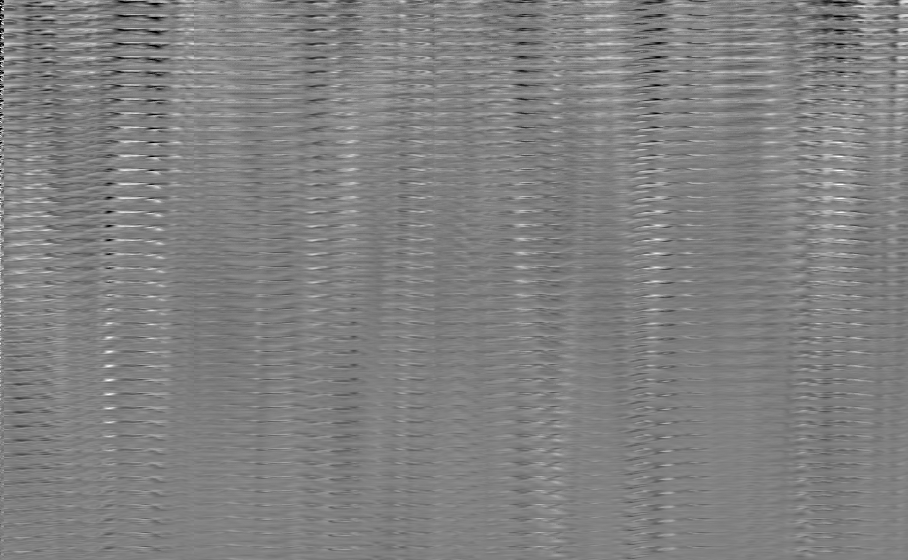

In [4]:
# 4. Inference and Visualization Example
# Select example images
folders = train.FolderName.unique()
example_folder = folders[0]
example_side = 'L'
labels, imgs = get_images_labels(PATH, f'{example_folder}_{example_side}_')
stacked_image, _ = prepare_stacked_data(imgs[20:60], labels[20:60])  # Stack first 5 images
stacked_image


0: 416x640 126 roots, 15.5ms
Speed: 1.4ms preprocess, 15.5ms inference, 10.2ms postprocess per image at shape (1, 3, 416, 640)


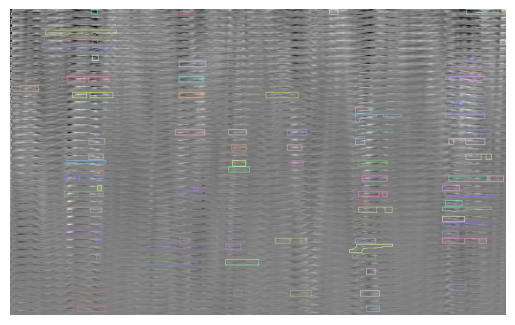

In [7]:
# Load trained model
model = YOLO('./runs/segment/train7/weights/best.pt')  # Adjust path if necessary

# Perform inference
results = model(stacked_image)
polygons = results[0].masks.xy
visualize(stacked_image, polygons)